In [88]:
# Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# PCA Libraries
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('dataset/googleplaystore_cleaned.csv')

### Objective 1: Hit or Miss Prediction

In [89]:
# Success dataframe
df['Success'] = (df['Installs'] > 100_000).astype(int)

# Select features and target variable
features = [
  'Category',
  'Size',
  'Type',
  'Price',
  'Content Rating',
]

X = df[features]
y = df['Success']

# Encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True, columns=['Category','Type','Content Rating', 'Size'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=67)

# Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=67, n_jobs=-1)

# Train the model
rf_classifier.fit(X_train, y_train)

# Predictions
y_pred = rf_classifier.predict(X_test)

In [90]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Miss', 'Hit']))

Classification Report:
              precision    recall  f1-score   support

        Miss       0.72      0.79      0.75      1136
         Hit       0.65      0.57      0.61       796

    accuracy                           0.70      1932
   macro avg       0.69      0.68      0.68      1932
weighted avg       0.69      0.70      0.69      1932



In [91]:
# Examine feature importance
importances = rf_classifier.feature_importances_
feature_names = X_encoded.columns

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
495,Size_Varies with device,0.106985
0,Price,0.035385
33,Type_Paid,0.034380
14,Category_GAME,0.031087
20,Category_MEDICAL,0.019760
36,Content Rating_Teen,0.019514
11,Category_FAMILY,0.013671
34,Content Rating_Everyone 10+,0.012846
35,Content Rating_Mature 17+,0.012793
29,Category_TOOLS,0.011836


#### Application

In [92]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

def predict_app_success(model, training_columns):
    print("\n" + "="*40)
    print("APP SUCCESS PREDICTOR (100k+ Installs)")
    print("="*40)

    # User input for app features
    category = input("Enter App Category (e.g., GAME, PRODUCTIVITY): ").strip().upper()
    app_type = input("Enter App Type (Free/Paid): ").strip().capitalize()
    price = float(input("Enter App Price (e.g., 0.00 for Free): "))
    content_rating = input("Enter Content Rating (e.g., Everyone, Teen): ").strip().capitalize()
    varies = input("Does the app have variable size? (y/n): ").strip().lower()

    input_data = pd.DataFrame(0, index=[0], columns=training_columns)

    if 'Price' in training_columns:
        input_data['Price'] = price

    category_col = f'Category_{category}'
    if category_col in training_columns:
        input_data[category_col] = 1
    
    type_col = f'Type_{app_type}'
    if type_col in training_columns:
        input_data[type_col] = 1

    content_col = f'Content Rating_{content_rating}'
    if content_col in training_columns:
        input_data[content_col] = 1

    if varies == 'y' and 'Size_Varies with device' in training_columns:
        input_data['Size_Varies with device'] = 1

    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    print("\n--- RESULTS ---")
    if prediction == 1:
        print(f"Prediction: HIT (High Volume Expected)")
        print(f"Confidence: {probability * 100:.1f}%")
    else:
        print(f"Prediction: FLOP (Niche / Low Volume)")
        print(f"Confidence: {(1 - probability) * 100:.1f}%")
    print("="*40 + "\n")

In [93]:
# Run Script
# while True:
#     predict_app_success(rf_classifier, X_encoded.columns)
#     cont = input("Do you want to predict another app? (y/n): ").strip().lower()
#     if cont != 'y':
#         print("Exiting App Success Predictor. Goodbye!")
#         break

### Objective 2: Principal Component Analysis (PCA)

In [94]:
df_pca = df.copy()  # Preserve original

# 'Size' contains 'Varies with device' make it numeric
df_pca['Size'] = pd.to_numeric(df_pca['Size'], errors='coerce')

# fill with median
df_pca['Size'].fillna(df_pca['Size'].median(), inplace=True)

# Log-transform 'Installs' and 'Reviews'
df_pca['Installs'] = np.log1p(df_pca['Installs'] + 1)
df_pca['Reviews'] = np.log1p(df_pca['Reviews'] + 1)

# Continous features Only
continuous_features = ['Size', 'Installs', 'Rating', 'Reviews', 'Price']
X_continuous = df_pca[continuous_features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_continuous)

# PCA
pca = PCA()
pca.fit(X_scaled)

variance_ratios = pca.explained_variance_ratio_

In [95]:
variance_ratios_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(variance_ratios))],
    'Variance Ratio': variance_ratios
})
variance_ratios_df

,Principal Component,Variance Ratio
0,PC1,0.417742
1,PC2,0.200603
2,PC3,0.195960
3,PC4,0.177823
4,PC5,0.007872


In [96]:
# cumulative variance for pc1 and pc2

cumulative_variance = sum(variance_ratios[:2]) * 100
print(f"Cumulative Variance Explained by PC1 and PC2: {cumulative_variance:.2f}%")

Cumulative Variance Explained by PC1 and PC2: 61.83%


In [97]:
# Eigenvectors
components_df = pd.DataFrame(
  pca.components_,
  columns=continuous_features,
  index=[f'PC{i+1} (Eigenvector {i+1})' for i in range(len(variance_ratios))]
)

components_df

,Size,Installs,Rating,Reviews,Price
PC1 (Eigenvector 1),0.304502,0.662108,0.120680,0.670971,-0.064227
PC2 (Eigenvector 2),0.041372,0.093359,-0.549677,0.067068,0.826396
PC3 (Eigenvector 3),0.006490,-0.088208,0.824444,-0.010687,0.558887
PC4 (Eigenvector 4),0.951257,-0.233963,-0.021826,-0.198778,-0.019577
PC5 (Eigenvector 5),-0.025212,-0.700269,-0.055737,0.711107,-0.014412


#### Interpretation

- PC1 represents the viral reach of an app (Installs, Ratings, Reviews).

- PC2 captures the relationship between Rating and Price, indicating how price affects user ratings. High Price -> Low Rating, and Low Price -> High Rating.

- PC3 is similar to PC2 but in opposite direction.

- PC4 is just the Size of the app, which is not very important.

- PC5 is for Installs and Reviews, which seperate the apps with many installs and reviews from those with few.

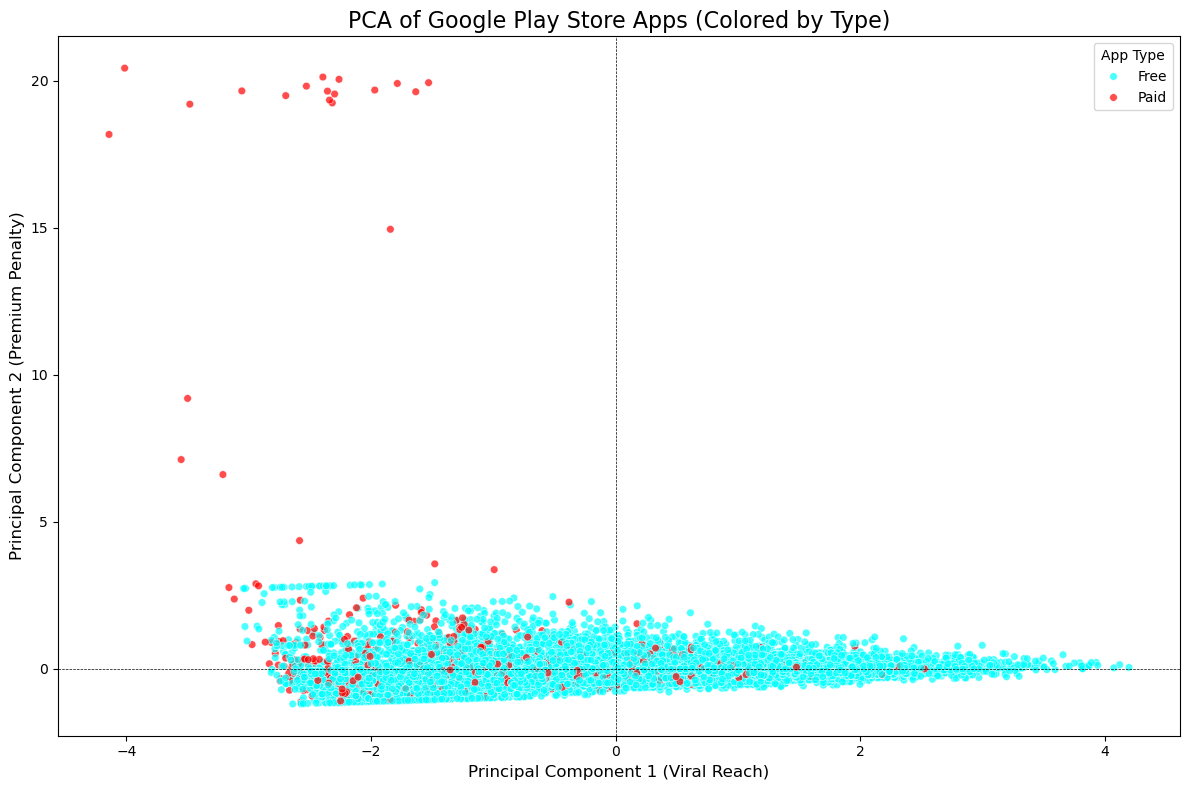

In [98]:
# Plotting the PCA
pca_2d = pca.transform(X_scaled)

pca_df = pd.DataFrame({
  'PC1 (Viral Reach)' : pca_2d[:, 0],
  'PC2 (Premium Penalty)' : pca_2d[:, 1],
  'App_type' : df_pca['Type'],
  'Category' : df_pca['Category']
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
  data=pca_df,
  x='PC1 (Viral Reach)',
  y='PC2 (Premium Penalty)',
  hue='App_type',
  palette={'Free': 'cyan', 'Paid': 'red'},
  alpha=0.7,
  s=30
)

plt.title('PCA of Google Play Store Apps (Colored by Type)', fontsize=16)
plt.xlabel('Principal Component 1 (Viral Reach)', fontsize=12)
plt.ylabel('Principal Component 2 (Premium Penalty)', fontsize=12)
plt.legend(title='App Type')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.axvline(0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.show()

This reveals the map of the app landscape. Notice that there's no red dots in the far-right, which means if an app wants to be a hit, it needs to be free. The paywall act as a barrier to success. 

There are red dots in the upper-left. These are apps like "I'm Rich" or expensive enterprise apps. This shows that high price, leads to lower installs.

At the bottom-center, there are some red dots, suggesting that Paid apps can still be hits, but only if they keep their "Premium Penalty".

In [99]:
pca_df['App_Name'] = df_pca['App'].values
pca_df['Price'] = df_pca['Price'].values
pca_df['Installs'] = df_pca['Installs'].values

pca_df.sort_values(by='PC1 (Viral Reach)', ascending=False).head(10)

,PC1 (Viral Reach),PC2 (Premium Penalty),App_type,Category,App_Name,Price,Installs
1372,4.198738,0.036797,Free,GAME,Clash of Clans,0.0,18.420681
1356,4.122653,0.130616,Free,GAME,Subway Surfers,0.0,20.723266
1362,4.074482,0.023846,Free,GAME,Clash Royale,0.0,18.420681
1399,3.942418,0.110447,Free,GAME,My Talking Angela,0.0,18.420681
1357,3.931444,0.204854,Free,GAME,Candy Crush Saga,0.0,20.030119
4456,3.890796,0.204026,Free,GAME,Mobile Legends: Bang Bang,0.0,18.420681
1424,3.876865,0.104426,Free,GAME,Hungry Shark Evolution,0.0,18.420681
1517,3.871329,0.100685,Free,GAME,Yes day,0.0,18.420681
3159,3.871290,0.100681,Free,FAMILY,Hay Day,0.0,18.420681
1404,3.820046,-0.002118,Free,GAME,Score! Hero,0.0,18.420681


In [100]:
# 1. Map the original app names, prices, and installs back into our PCA DataFrame

# 2. Filter for the extreme mathematical outliers (The top-left cluster)
extreme_outliers = pca_df[pca_df['PC2 (Premium Penalty)'] > 10]

# 3. Sort them from most extreme to least extreme
top_outliers = extreme_outliers.sort_values(by='PC2 (Premium Penalty)', ascending=False)

# 4. Print the exact details
print("\n--- THE 'EXTREME PREMIUM' OUTLIERS ---")
top_outliers[['App_Name', 'Category', 'Price', 'Installs']].head(25)


--- THE 'EXTREME PREMIUM' OUTLIERS ---


,App_Name,Category,Price,Installs
8780,I'm Rich/Eu sou Rico/أنا غني/我很有錢,LIFESTYLE,399.99,0.693147
4403,I am rich(premium),FINANCE,399.99,8.517593
3469,I'm Rich - Trump Edition,LIFESTYLE,400.00,9.210540
4396,I am rich,LIFESTYLE,399.99,11.512945
3465,💎 I'm rich,LIFESTYLE,399.99,9.210540
4402,I am Rich!,FINANCE,399.99,6.909753
4398,I am Rich Plus,FAMILY,399.99,9.210540
4401,I am extremely Rich,LIFESTYLE,379.99,6.909753
4417,I AM RICH PRO PLUS,FINANCE,399.99,6.909753
4400,I Am Rich Premium,FINANCE,399.99,10.819818
